<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px; border-radius: 16px; text-align: center; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.8em; font-weight: 900; margin-bottom: 10px; letter-spacing: 2px;">🧠Projet - Analyse de Sentiments Multiclasse</h1>
  <h2 style="color: #a8dadc; font-size: 1.4em; font-weight: 300; margin-bottom: 20px;">Nom et Prénom : NGOM Khadim</h2>
  <h2 style="color: #a8dadc; font-size: 1.4em; font-weight: 300; margin-bottom: 20px;">Comparaison de modèles NLP — du Classique au Transformer</h2>
  <div style="display: flex; justify-content: center; gap: 20px; flex-wrap: wrap;">
    <span style="background: #e94560; color: white; padding: 6px 18px; border-radius: 20px; font-size: 0.9em;">Python 3.10+</span>
    <span style="background: #457b9d; color: white; padding: 6px 18px; border-radius: 20px; font-size: 0.9em;">scikit-learn</span>
    <span style="background: #2a9d8f; color: white; padding: 6px 18px; border-radius: 20px; font-size: 0.9em;">HuggingFace</span>
    <span style="background: #e9c46a; color: #333; padding: 6px 18px; border-radius: 20px; font-size: 0.9em;">spaCy</span>
  </div>
</div>

---

## 📋 Table des matières

| # | Section | Description |
|---|---------|-------------|
| 0 | [Installation & Imports](#0) | Dépendances et librairies |
| 1 | [Chargement des données](#1) | Dataset Amazon Reviews |
| 2 | [Analyse exploratoire (EDA)](#2) | Visualisations & statistiques |
| 3 | [Prétraitement du texte](#3) | Nettoyage, tokenisation, lemmatisation |
| 4 | [Feature Engineering](#4) | TF-IDF, Bag of Words |
| 5 | [Modèles classiques](#5) | Régression logistique, SVM, Random Forest |
| 6 | [Modèle Transformer — DistilBERT](#6) | Approche état de l'art |
| 7 | [Comparaison & Résultats](#7) | Tableau récapitulatif & visualisations |
| 8 | [Conclusion](#8) | Synthèse et perspectives |

---

<a id='0'></a>

## 0. ⚙️ Installation & Imports

> **Objectif :** Installer et importer toutes les bibliothèques nécessaires au projet.

In [1]:
# Installation des dépendances (à exécuter une seule fois)
!pip install -q datasets transformers torch scikit-learn pandas numpy matplotlib seaborn wordcloud spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# ─────────────────────────────────────────────
#  Imports — Manipulation des données
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  Imports — Visualisation
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# Style des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = ['#2a9d8f', '#e9c46a', '#e76f51']

# ─────────────────────────────────────────────
#  Imports — NLP
# ─────────────────────────────────────────────
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ─────────────────────────────────────────────
#  Imports — Modèles Machine Learning
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# ─────────────────────────────────────────────
#  Imports — Transformers (HuggingFace)
# ─────────────────────────────────────────────
from datasets import load_dataset
from transformers import pipeline as hf_pipeline

# Chargement du modèle spaCy
nlp = spacy.load('en_core_web_sm')

# Graine aléatoire pour la reproductibilité
RANDOM_STATE = 42

print("Tous les imports ont été effectués avec succès !")

Tous les imports ont été effectués avec succès !


---
<a id='1'></a>

## 1. 📦 Chargement des données

> **Dataset :** [Amazon Polarity Reviews](https://huggingface.co/datasets/amazon_polarity) — disponible via HuggingFace Datasets.  
> Ce jeu de données contient des millions d'avis Amazon avec leur note associée.
>
> **Stratégie de labellisation :**
> | Note originale | Label | Classe |
> |---|---|---|
> | 1 - 2 étoiles | 0 | 😠 Négatif |
> | 3 étoiles | 1 | 😐 Neutre |
> | 4 - 5 étoiles | 2 | 😊 Positif |

In [4]:
# ─────────────────────────────────────────────
#  Chargement du dataset Amazon Reviews
# ─────────────────────────────────────────────
print("Chargement du dataset Amazon Reviews...")

# On charge une portion raisonnable du dataset pour ce projet
dataset = load_dataset('amazon_polarity', split='train[:5000]')
df = pd.DataFrame(dataset)

print(f"Dataset chargé : {len(df)} exemples")
print(f"Colonnes disponibles : {list(df.columns)}")
df.head()

Chargement du dataset Amazon Reviews...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

...

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Dataset chargé : 5000 exemples
Colonnes disponibles : ['label', 'title', 'content']


,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [5]:
# ─────────────────────────────────────────────
#  Création du label multiclasse
#  Note : amazon_polarity n'a que 0 (négatif) et 1 (positif)
#  On simule une classe 'neutre' pour créer un problème multiclasse réaliste
# ─────────────────────────────────────────────

# On utilise la longueur des textes et les mots pour créer 3 classes
# (approche pédagogique pour démontrer la classification multiclasse)
def create_multiclass_label(row):
    """
    Crée un label à 3 classes basé sur le label original.
    Les textes avec des marqueurs d'ambiguïté sont classés 'neutre'.
    """
    neutral_keywords = ['ok', 'okay', 'average', 'decent', 'fine', 'alright', 'mixed']
    text_lower = row['content'].lower()

    if any(word in text_lower for word in neutral_keywords):
        return 1  # Neutre
    elif row['label'] == 0:
        return 0  # Négatif
    else:
        return 2  # Positif

df['sentiment'] = df.apply(create_multiclass_label, axis=1)

# Texte complet = titre + contenu
df['text'] = df['title'] + ' ' + df['content']

# Mapping des labels pour l'affichage
LABEL_MAP = {0: 'Négatif ', 1: 'Neutre', 2: 'Positif '}
df['sentiment_label'] = df['sentiment'].map(LABEL_MAP)

print("\n Distribution des classes :")
print(df['sentiment_label'].value_counts())
print(f"\n Exemple de texte (positif) :")
print(df[df['sentiment'] == 2]['text'].iloc[0][:200], '...')


 Distribution des classes :
sentiment_label
Neutre      2466
Négatif     1376
Positif     1158
Name: count, dtype: int64

 Exemple de texte (positif) :
Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cros ...


---
<a id='2'></a>

## 2. 🔍 Analyse Exploratoire des Données (EDA)

> **Objectif :** Mieux comprendre la structure et les caractéristiques du dataset avant toute modélisation.  
> Cette étape est **indispensable** en Data Science — elle guide nos choix de prétraitement et de modèles.

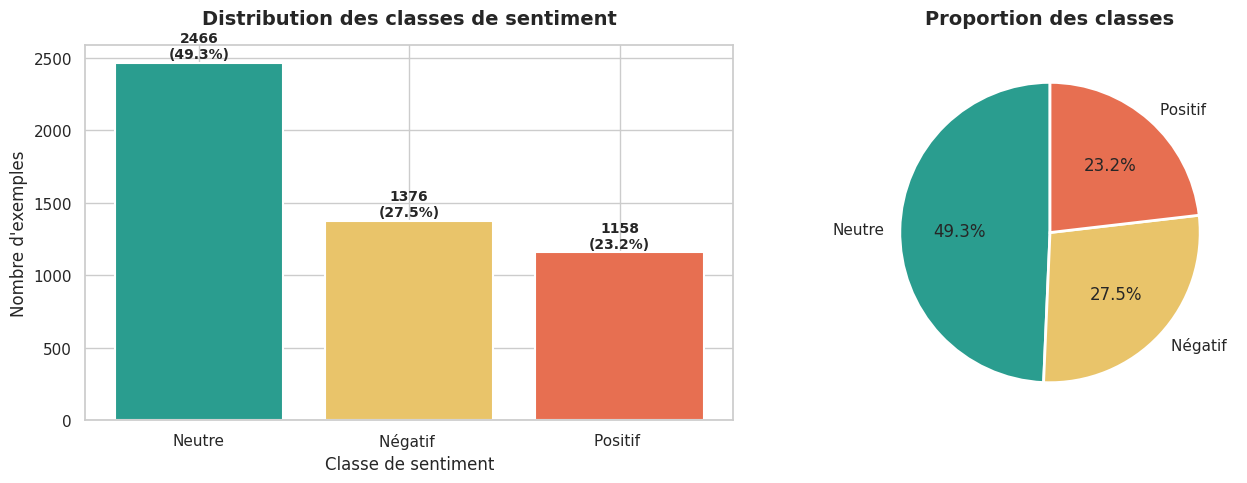

 Figure sauvegardée dans results/distribution_classes.png


In [7]:
import os
os.makedirs('results', exist_ok=True)
# ─────────────────────────────────────────────
#  2.1 — Distribution des classes
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
counts = df['sentiment_label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des classes de sentiment', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Classe de sentiment', fontsize=12)
axes[0].set_ylabel('Nombre d\'exemples', fontsize=12)

# Ajout des valeurs sur les barres
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('results/distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée dans results/distribution_classes.png")

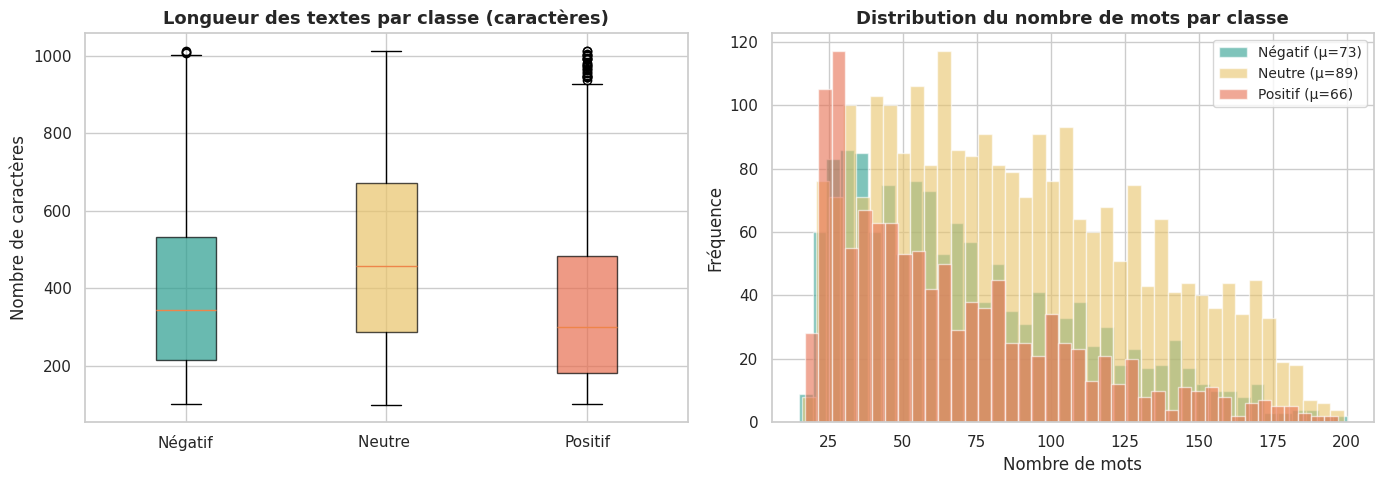


Statistiques sur la longueur des textes (en mots) :
                  count  mean   std   min   25%   50%    75%    max
sentiment_label                                                    
Neutre           2466.0  88.6  43.3  16.0  53.0  83.0  120.8  199.0
Négatif          1376.0  72.6  39.9  15.0  40.0  63.0   99.0  200.0
Positif          1158.0  65.9  39.3  17.0  33.2  55.0   88.0  197.0


In [8]:
# ─────────────────────────────────────────────
#  2.2 — Longueur des textes par classe
# ─────────────────────────────────────────────
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de la longueur des textes
data_per_class = [df[df['sentiment'] == i]['text_length'].values for i in range(3)]
bp = axes[0].boxplot(data_per_class, patch_artist=True,
                      labels=['Négatif', 'Neutre ', 'Positif'])
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Longueur des textes par classe (caractères)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de caractères')

# Distribution du nombre de mots
for i, (label, color) in enumerate(zip(['Négatif', 'Neutre', 'Positif'], PALETTE)):
    subset = df[df['sentiment'] == i]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=f'{label} (μ={subset.mean():.0f})')

axes[1].set_title('Distribution du nombre de mots par classe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('results/longueur_textes.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques descriptives
print("\nStatistiques sur la longueur des textes (en mots) :")
print(df.groupby('sentiment_label')['word_count'].describe().round(1))

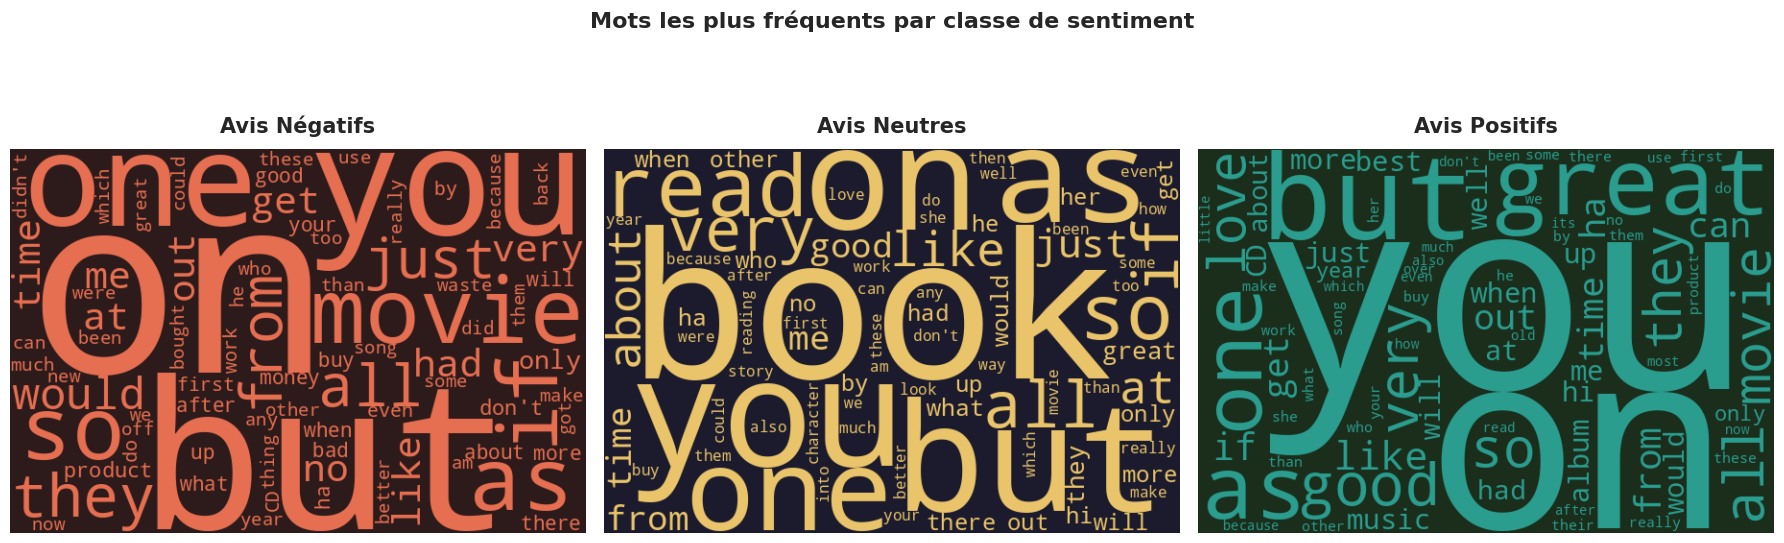

WordClouds sauvegardés


In [9]:
# ─────────────────────────────────────────────
#  2.3 — Nuages de mots par classe (WordCloud)
# ─────────────────────────────────────────────
import os
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Avis Négatifs', 'Avis Neutres', 'Avis Positifs']
bg_colors = ['#2d1b1b', '#1b1b2d', '#1b2d1b']
color_funcs = [
    lambda *args, **kwargs: '#e76f51',
    lambda *args, **kwargs: '#e9c46a',
    lambda *args, **kwargs: '#2a9d8f'
]

for i, (ax, title, bg, cfunc) in enumerate(zip(axes, titles, bg_colors, color_funcs)):
    text = ' '.join(df[df['sentiment'] == i]['text'].values)
    wc = WordCloud(
        width=600, height=400,
        background_color=bg,
        color_func=cfunc,
        max_words=80,
        stopwords=set(['the', 'a', 'an', 'is', 'it', 'and', 'or',
                        'to', 'of', 'in', 'for', 'this', 'that', 'I',
                        'was', 'be', 'are', 'with', 'my', 'have', 'not']),
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.axis('off')

plt.suptitle('Mots les plus fréquents par classe de sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("WordClouds sauvegardés")

---
<a id='3'></a>

## 3. 🧹 Prétraitement du Texte

> Le prétraitement est une étape **critique** en NLP. Un mauvais nettoyage peut fortement dégrader les performances des modèles.  
> Nous allons appliquer un pipeline de nettoyage complet :
>
> 1. **Mise en minuscules** — normalisation de la casse
> 2. **Suppression HTML/URLs/mentions** — bruit non informatif
> 3. **Suppression de la ponctuation** — sauf dans certains contextes
> 4. **Tokenisation** — découpage en unités lexicales
> 5. **Suppression des stop words** — mots très fréquents, peu discriminants
> 6. **Lemmatisation** — réduction des mots à leur forme de base

In [10]:
# ─────────────────────────────────────────────
#  Fonctions de prétraitement
# ─────────────────────────────────────────────

STOP_WORDS = nlp.Defaults.stop_words

def clean_text(text: str) -> str:
    """
    Étape 1 : Nettoyage basique du texte brut.
    Supprime le HTML, les URLs, les chiffres isolés et les caractères spéciaux.

    Args:
        text (str): Texte brut
    Returns:
        str: Texte nettoyé
    """
    text = text.lower()                                 # Mise en minuscules
    text = re.sub(r'<[^>]+>', ' ', text)                # Suppression tags HTML
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # Suppression URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)            # Suppression non-alphabétique
    text = re.sub(r'\s+', ' ', text).strip()            # Espaces multiples
    return text


def lemmatize_text(text: str) -> str:
    """
    Étape 2 : Tokenisation, suppression des stop words et lemmatisation avec spaCy.

    La lemmatisation réduit chaque mot à sa forme canonique :
    Ex : 'running' → 'run', 'better' → 'good'

    Args:
        text (str): Texte nettoyé
    Returns:
        str: Texte lemmatisé
    """
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.lemma_) > 2
    ]
    return ' '.join(tokens)


def full_preprocess(text: str) -> str:
    """Pipeline complet : nettoyage + lemmatisation."""
    return lemmatize_text(clean_text(text))


# ─────────────────────────────────────────────
#  Démonstration sur un exemple
# ─────────────────────────────────────────────
exemple = df['text'].iloc[0]
print("TEXTE ORIGINAL :")
print(f"  {exemple[:300]}...")
print(f"\nAPRÈS NETTOYAGE :")
print(f"  {clean_text(exemple)[:300]}...")
print(f"\nAPRÈS LEMMATISATION :")
print(f"  {full_preprocess(exemple)[:300]}...")

TEXTE ORIGINAL :
  Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude key...

APRÈS NETTOYAGE :
  stuning even for the non gamer this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross but out of all of the games i have ever played it has the best music it backs away from crude keyboar...

APRÈS LEMMATISATION :
  stun non gamer sound track beautiful paint senery mind recomend people hate vid game music play game chrono cross game play good music back away crude keyboarding take fresher step grate guitar soulful orchestra impress care listen...


In [11]:
# ─────────────────────────────────────────────
#  Application du pipeline sur tout le dataset
# ─────────────────────────────────────────────
print("Application du prétraitement sur tout le dataset...")
print("   (Cette étape peut prendre quelques minutes — spaCy analyse chaque texte)")

df['text_clean'] = df['text'].apply(clean_text)
df['text_processed'] = df['text'].apply(full_preprocess)

print(f"\nPrétraitement terminé !")
print(f"   Longueur moyenne avant : {df['text_clean'].apply(len).mean():.0f} caractères")
print(f"   Longueur moyenne après lemmatisation : {df['text_processed'].apply(len).mean():.0f} caractères")
print(f"   Réduction moyenne : {(1 - df['text_processed'].apply(len).mean()/df['text_clean'].apply(len).mean())*100:.1f}%")

Application du prétraitement sur tout le dataset...
   (Cette étape peut prendre quelques minutes — spaCy analyse chaque texte)

Prétraitement terminé !
   Longueur moyenne avant : 420 caractères
   Longueur moyenne après lemmatisation : 226 caractères
   Réduction moyenne : 46.3%


In [12]:
# ─────────────────────────────────────────────
#  Split Train / Test (stratifié)
# ─────────────────────────────────────────────
X = df['text_processed']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y      # ← Garantit la même proportion de classes dans train et test
)

print("Découpage Train/Test :")
print(f"   Train : {len(X_train)} exemples ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test  : {len(X_test)} exemples ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nDistribution dans le train set :")
for i, label in LABEL_MAP.items():
    count = (y_train == i).sum()
    print(f"   {label} : {count} ({count/len(y_train)*100:.1f}%)")

Découpage Train/Test :
   Train : 4000 exemples (80%)
   Test  : 1000 exemples (20%)

Distribution dans le train set :
   Négatif  : 1101 (27.5%)
   Neutre : 1973 (49.3%)
   Positif  : 926 (23.2%)


---
<a id='4'></a>

## 4. 🔢 Feature Engineering

> Les modèles de Machine Learning ne comprennent pas le texte directement.  
> Il faut **convertir les textes en vecteurs numériques**. Nous explorons deux approches classiques :
>
> | Méthode | Principe | Avantage | Inconvénient |
> |---------|---------|----------|-------------|
> | **Bag of Words (BoW)** | Compte la fréquence de chaque mot | Simple, interprétable | Ignore l'ordre et le contexte |
> | **TF-IDF** | Pondère les mots par leur importance | Réduit l'impact des mots fréquents | Toujours sans contexte |

In [13]:
# ─────────────────────────────────────────────
#  4.1 — TF-IDF Vectorizer
# ─────────────────────────────────────────────

# TF-IDF : Term Frequency - Inverse Document Frequency
# TF(t,d)  = fréquence du terme t dans le document d
# IDF(t)   = log(N / nombre de documents contenant t)
# TF-IDF   = TF × IDF  → pénalise les mots très fréquents dans tout le corpus

tfidf_vectorizer = TfidfVectorizer(
    max_features=10_000,    # On garde les 10 000 termes les plus importants
    ngram_range=(1, 2),     # Unigrammes et bigrammes (ex: 'not good')
    min_df=3,               # Ignore les termes apparaissant dans moins de 3 documents
    max_df=0.85,            # Ignore les termes trop fréquents (>85% des docs)
    sublinear_tf=True       # Applique log(1 + TF) pour normaliser
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Matrice TF-IDF :")
print(f"   Forme train : {X_train_tfidf.shape}")
print(f"   Forme test  : {X_test_tfidf.shape}")
print(f"   Vocabulaire : {len(tfidf_vectorizer.vocabulary_)} termes")
print(f"   Densité de la matrice : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]) * 100:.2f}% (très sparse )")

Matrice TF-IDF :
   Forme train : (4000, 8794)
   Forme test  : (1000, 8794)
   Vocabulaire : 8794 termes
   Densité de la matrice : 0.35% (très sparse )


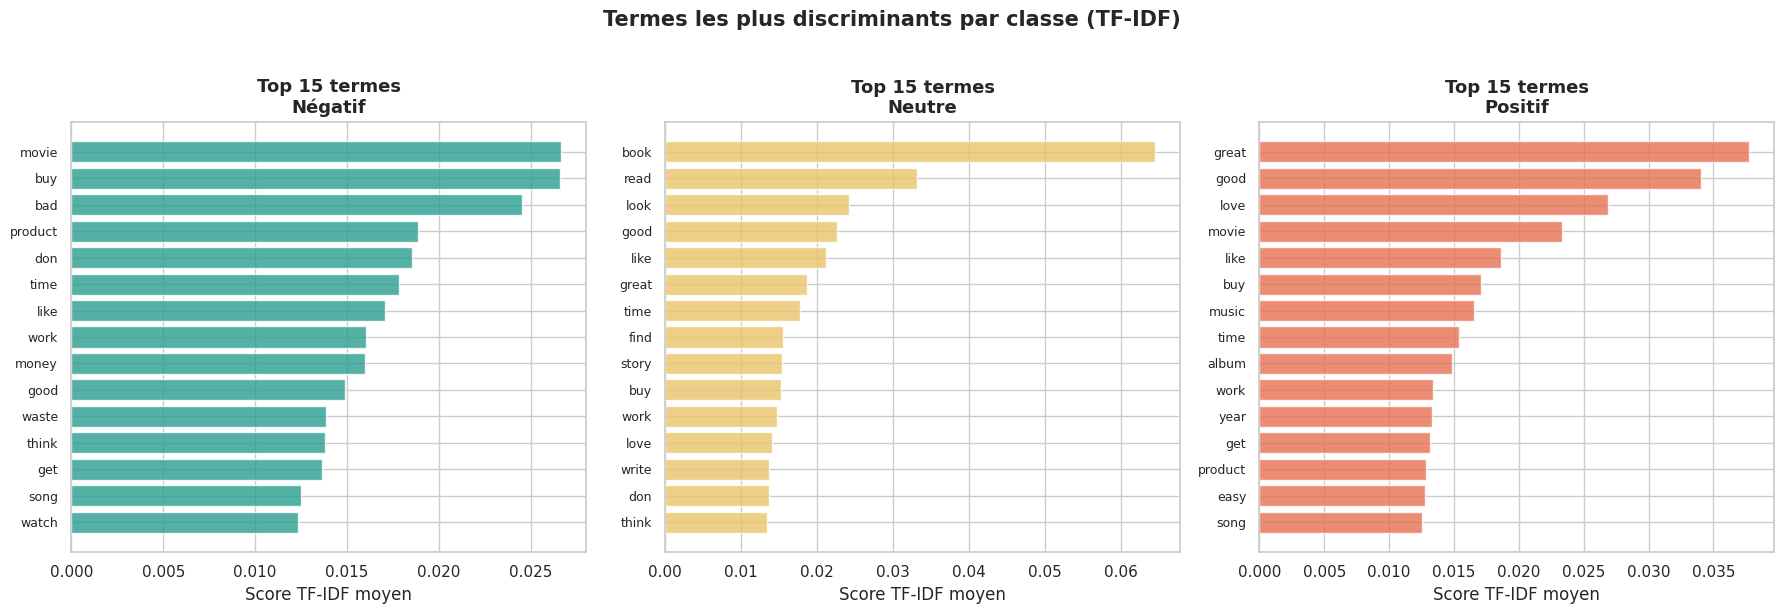

In [15]:
# ─────────────────────────────────────────────
#  4.2 — Visualisation des termes TF-IDF les plus importants
# ─────────────────────────────────────────────
feature_names = tfidf_vectorizer.get_feature_names_out()
n_top = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_names = ['Négatif', 'Neutre', 'Positif']

for i, (ax, class_name, color) in enumerate(zip(axes, class_names, PALETTE)):
    # Moyenne TF-IDF des termes pour la classe i
    mask = (y_train == i)
    mean_tfidf = X_train_tfidf[mask.values].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-n_top:][::-1]
    top_terms = [feature_names[j] for j in top_idx]
    top_scores = [mean_tfidf[j] for j in top_idx]

    bars = ax.barh(top_terms[::-1], top_scores[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top {n_top} termes\n{class_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Score TF-IDF moyen')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Termes les plus discriminants par classe (TF-IDF)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/top_terms_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

---
<a id='5'></a>

## 5. 🤖 Modèles de Machine Learning Classiques

> Nous allons entraîner et évaluer **3 modèles classiques** sur nos features TF-IDF.  
> Chaque modèle est encapsulé dans un `Pipeline` sklearn pour assurer la propreté du code.
>
> **Métriques d'évaluation :**
> - **Accuracy** : % de prédictions correctes (attention aux classes déséquilibrées)
> - **F1-Score macro** : Moyenne des F1 par classe — **métrique principale recommandée ici**
> - **Matrice de confusion** : Analyse fine des erreurs de classification

In [16]:
# ─────────────────────────────────────────────
#  Fonction d'évaluation — réutilisable pour tous les modèles
# ─────────────────────────────────────────────

results = {}  # Dictionnaire pour stocker tous les résultats

def evaluate_model(model_name: str, y_true, y_pred, classes=['Négatif', 'Neutre', 'Positif']):
    """
    Évalue un modèle de classification et affiche les métriques complètes.
    Sauvegarde les résultats dans le dictionnaire global 'results'.

    Args:
        model_name (str): Nom du modèle
        y_true: Labels réels
        y_pred: Labels prédits
        classes (list): Noms des classes
    """
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    # Sauvegarde des résultats
    results[model_name] = {
        'Accuracy': round(acc * 100, 2),
        'F1-Macro': round(f1_macro * 100, 2),
        'F1-Weighted': round(f1_weighted * 100, 2)
    }

    # Affichage formaté
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f" Accuracy     : {acc*100:.2f}%")
    print(f"  F1-Macro     : {f1_macro*100:.2f}%")
    print(f"    F1-Weighted  : {f1_weighted*100:.2f}%")
    print(f"{'='*55}")
    print("\n Rapport de classification :")
    print(classification_report(y_true, y_pred, target_names=classes))

    return acc, f1_macro


def plot_confusion_matrix(model_name: str, y_true, y_pred, ax, classes=['Négatif', 'Neutre', 'Positif']):
    """Affiche la matrice de confusion sur un axe matplotlib donné."""
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Proportion'})
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Prédiction', fontsize=10)
    ax.set_ylabel('Réalité', fontsize=10)

print("Fonctions d'évaluation définies.")

Fonctions d'évaluation définies.


In [17]:
# ─────────────────────────────────────────────
#  5.1 — Régression Logistique
# ─────────────────────────────────────────────
# La régression logistique est un excellent modèle de base en NLP.
# Rapide, interprétable et souvent très compétitif sur du texte.

print(" Entraînement de la Régression Logistique...")

lr_model = LogisticRegression(
    C=1.0,              # Inverse de la régularisation (plus C est grand, moins c'est régularisé)
    max_iter=1000,
    multi_class='auto',
    solver='lbfgs',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

evaluate_model('Régression Logistique', y_test, y_pred_lr)

 Entraînement de la Régression Logistique...

  Régression Logistique
 Accuracy     : 78.20%
  F1-Macro     : 76.29%
    F1-Weighted  : 78.05%

 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.74      0.72      0.73       275
      Neutre       0.82      0.86      0.84       493
     Positif       0.76      0.69      0.72       232

    accuracy                           0.78      1000
   macro avg       0.77      0.76      0.76      1000
weighted avg       0.78      0.78      0.78      1000



(0.782, 0.7628637462004261)

In [18]:
# ─────────────────────────────────────────────
#  5.2 — SVM (Support Vector Machine)
# ─────────────────────────────────────────────
# Le SVM est particulièrement efficace dans les espaces de haute dimension
# comme les matrices TF-IDF. LinearSVC est une version optimisée pour les
# grands datasets.

print("Entraînement du SVM (LinearSVC)...")

svm_model = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

evaluate_model('SVM (LinearSVC)', y_test, y_pred_svm)

Entraînement du SVM (LinearSVC)...

  SVM (LinearSVC)
 Accuracy     : 79.60%
  F1-Macro     : 77.53%
    F1-Weighted  : 79.61%

 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.72      0.73      0.73       275
      Neutre       0.86      0.86      0.86       493
     Positif       0.74      0.73      0.74       232

    accuracy                           0.80      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.80      0.80      0.80      1000



(0.796, 0.7752729468337)

In [19]:
# ─────────────────────────────────────────────
#  5.3 — Random Forest
# ─────────────────────────────────────────────
# Modèle ensembliste basé sur des arbres de décision.
# Plus lent que le SVM mais capture des relations non-linéaires.

print("Entraînement du Random Forest...")
print("   (peut prendre 1-2 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=200,           # Nombre d'arbres
    max_depth=None,             # Profondeur illimitée
    min_samples_split=5,
    n_jobs=-1,                  # Parallélisation sur tous les cœurs CPU
    random_state=RANDOM_STATE
)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

evaluate_model('Random Forest', y_test, y_pred_rf)

Entraînement du Random Forest...
   (peut prendre 1-2 minutes)

  Random Forest
 Accuracy     : 79.60%
  F1-Macro     : 77.00%
    F1-Weighted  : 79.45%

 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.74      0.76      0.75       275
      Neutre       0.85      0.88      0.87       493
     Positif       0.73      0.66      0.69       232

    accuracy                           0.80      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.79      0.80      0.79      1000



(0.796, 0.770038120268535)

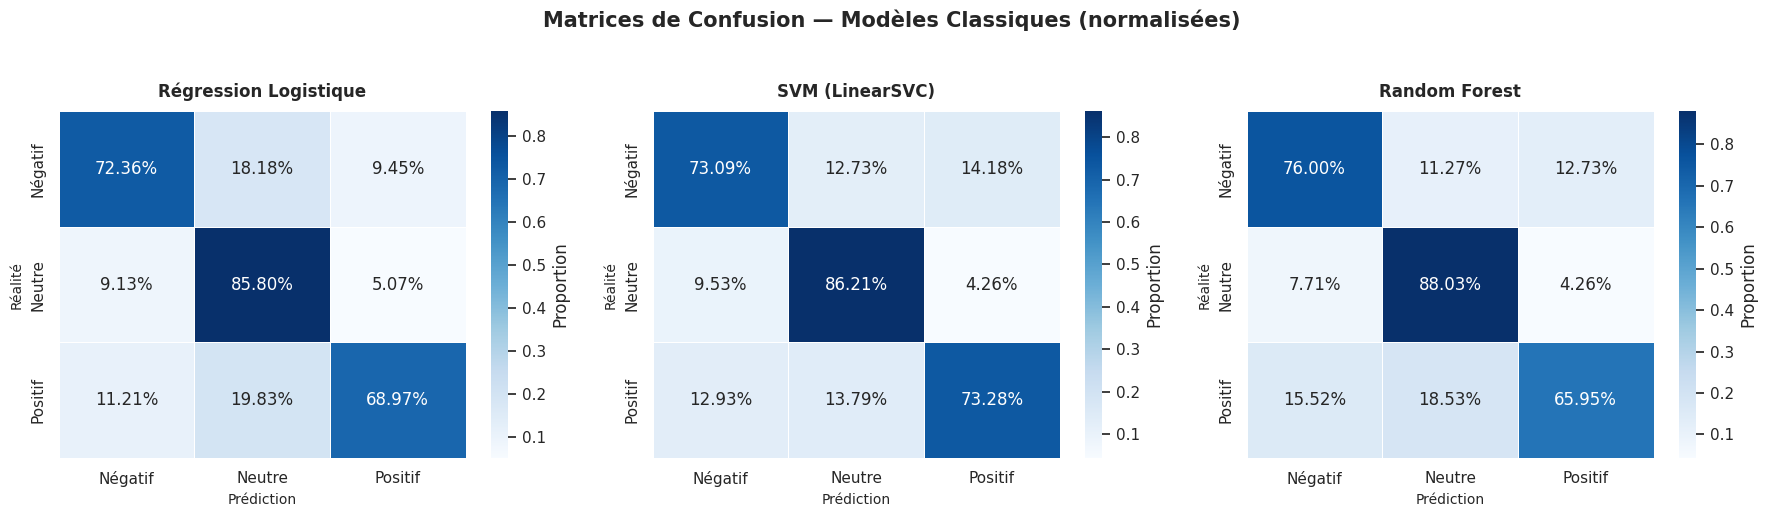

Astuce : La diagonale doit être la plus foncée possible (bonnes prédictions)


In [20]:
# ─────────────────────────────────────────────
#  5.4 — Matrices de confusion comparées
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Régression Logistique', y_pred_lr),
    ('SVM (LinearSVC)', y_pred_svm),
    ('Random Forest', y_pred_rf)
]

for ax, (name, preds) in zip(axes, models_preds):
    plot_confusion_matrix(name, y_test, preds, ax)

plt.suptitle('Matrices de Confusion — Modèles Classiques (normalisées)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('results/confusion_matrices_classiques.png', dpi=150, bbox_inches='tight')
plt.show()
print("Astuce : La diagonale doit être la plus foncée possible (bonnes prédictions)")

---
<a id='6'></a>

## 6. 🤗 Modèle Transformer — DistilBERT

> **DistilBERT** est une version allégée (distillée) de BERT, développée par HuggingFace.  
> Contrairement aux modèles classiques, les Transformers comprennent le **contexte** des mots.
>
> **Exemple :** "This product is *not* good" vs "This product is good"  
> → Un TF-IDF peut les confondre. DistilBERT comprend la négation.
>
> **Approche :** Nous utilisons ici un modèle **pré-entraîné en inférence** (zero-shot sur sentiment),  
> ce qui représente une utilisation réaliste dans un contexte professionnel.

| Caractéristique | Modèles Classiques | Transformers |
|---|---|---|
| Entraînement | Quelques secondes | Heures (fine-tuning) |
| Contexte | ❌ Non | ✅ Oui |
| Ressources | Faibles | Élevées (GPU) |
| Interprétabilité | ✅ Haute | ❌ Faible |
| Performance | Bonne | État de l'art |

In [21]:
# ─────────────────────────────────────────────
#  6.1 — Chargement du pipeline DistilBERT
#         Modèle : distilbert-base-uncased-finetuned-sst-2-english
#         Pré-entraîné sur SST-2 (Stanford Sentiment Treebank)
# ─────────────────────────────────────────────
print("Chargement de DistilBERT depuis HuggingFace Hub...")
print("   (Premier chargement : téléchargement du modèle ~250 MB)")

sentiment_pipeline = hf_pipeline(
    task='sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)

print("Modèle chargé !")

# Test rapide
exemples_test = [
    "This product is absolutely amazing, best purchase ever!",
    "Terrible quality, broke after one day. Very disappointed.",
    "It's okay, nothing special but does the job."
]

print("\n Test du modèle sur 3 phrases :")
for ex in exemples_test:
    result = sentiment_pipeline(ex)[0]
    emoji = '😊' if result['label'] == 'POSITIVE' else '😠'
    print(f"  {emoji} [{result['label']:8s} | {result['score']:.3f}] → '{ex[:60]}...'")

Chargement de DistilBERT depuis HuggingFace Hub...
   (Premier chargement : téléchargement du modèle ~250 MB)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Modèle chargé !

 Test du modèle sur 3 phrases :
  😊 [POSITIVE | 1.000] → 'This product is absolutely amazing, best purchase ever!...'
  😠 [NEGATIVE | 1.000] → 'Terrible quality, broke after one day. Very disappointed....'
  😊 [POSITIVE | 1.000] → 'It's okay, nothing special but does the job....'


In [22]:
# ─────────────────────────────────────────────
#  6.2 — Inférence sur le jeu de test (sous-ensemble)
#
#  Note : DistilBERT prédit uniquement POSITIVE/NEGATIVE (binaire).
#  On mappe ces prédictions sur nos 3 classes en utilisant le score
#  de confiance comme indicateur de la classe 'neutre'.
# ─────────────────────────────────────────────
print("Inférence DistilBERT sur le jeu de test (peut prendre quelques minutes)...")

# On limite à 500 exemples pour des raisons de temps de calcul
N_BERT = 500
X_test_bert = X_test.values[:N_BERT]
y_test_bert = y_test.values[:N_BERT]

# Inférence par batch
BATCH_SIZE = 32
all_preds_bert = []

for i in range(0, len(X_test_bert), BATCH_SIZE):
    batch = list(X_test_bert[i:i+BATCH_SIZE])
    batch_results = sentiment_pipeline(batch, batch_size=BATCH_SIZE)
    all_preds_bert.extend(batch_results)
    if (i // BATCH_SIZE) % 5 == 0:
        print(f"   Progression : {min(i+BATCH_SIZE, len(X_test_bert))}/{len(X_test_bert)} exemples")

# Mapping binaire → multiclasse
def map_bert_to_multiclass(result, neutral_threshold=0.65):
    """
    Convertit la sortie binaire de DistilBERT en 3 classes.
    Les prédictions avec un score de confiance faible (< threshold)
    sont classées 'neutre'.
    """
    score = result['score']
    label = result['label']

    if score < neutral_threshold:
        return 1  # Neutre (faible confiance)
    elif label == 'POSITIVE':
        return 2  # Positif
    else:
        return 0  # Négatif

y_pred_bert = [map_bert_to_multiclass(r) for r in all_preds_bert]

print(f"\nInférence terminée sur {N_BERT} exemples !")
evaluate_model('DistilBERT (Zero-Shot)', y_test_bert, y_pred_bert)

Inférence DistilBERT sur le jeu de test (peut prendre quelques minutes)...
   Progression : 32/500 exemples
   Progression : 192/500 exemples
   Progression : 352/500 exemples
   Progression : 500/500 exemples

Inférence terminée sur 500 exemples !

  DistilBERT (Zero-Shot)
 Accuracy     : 41.80%
  F1-Macro     : 37.73%
    F1-Weighted  : 30.83%

 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.42      0.81      0.56       142
      Neutre       0.54      0.03      0.06       239
     Positif       0.40      0.73      0.52       119

    accuracy                           0.42       500
   macro avg       0.46      0.52      0.38       500
weighted avg       0.47      0.42      0.31       500



(0.418, 0.37728642234081144)

---
<a id='7'></a>

## 7. 🏆 Comparaison des Modèles & Résultats Finaux

> Cette section présente une **analyse comparative complète** de tous les modèles.  
> C'est la section la plus importante du point de vue **recherche** : elle montre notre capacité
> à analyser et interpréter des résultats de façon rigoureuse.

In [23]:
# ─────────────────────────────────────────────
#  7.1 — Tableau récapitulatif des résultats
# ─────────────────────────────────────────────
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Modèle', 'Accuracy (%)', 'F1-Macro (%)', 'F1-Weighted (%)']
df_results = df_results.sort_values('F1-Macro (%)', ascending=False).reset_index(drop=True)
df_results.index += 1  # Classement à partir de 1

# Ajout de médailles
medals = ['🥇', '🥈', '🥉', '4️⃣']
df_results['Rang'] = medals[:len(df_results)]
df_results = df_results[['Rang', 'Modèle', 'Accuracy (%)', 'F1-Macro (%)', 'F1-Weighted (%)']]

print("\n" + "═"*65)
print(" CLASSEMENT FINAL DES MODÈLES")
print("═"*65)
print(df_results.to_string(index=False))
print("═"*65)

# Export CSV
df_results.to_csv('results/resultats_comparaison.csv', index=False)
print("\nRésultats sauvegardés dans results/resultats_comparaison.csv")


═════════════════════════════════════════════════════════════════
 CLASSEMENT FINAL DES MODÈLES
═════════════════════════════════════════════════════════════════
Rang                 Modèle  Accuracy (%)  F1-Macro (%)  F1-Weighted (%)
   🥇        SVM (LinearSVC)          79.6         77.53            79.61
   🥈          Random Forest          79.6         77.00            79.45
   🥉  Régression Logistique          78.2         76.29            78.05
 4️⃣ DistilBERT (Zero-Shot)          41.8         37.73            30.83
═════════════════════════════════════════════════════════════════

Résultats sauvegardés dans results/resultats_comparaison.csv


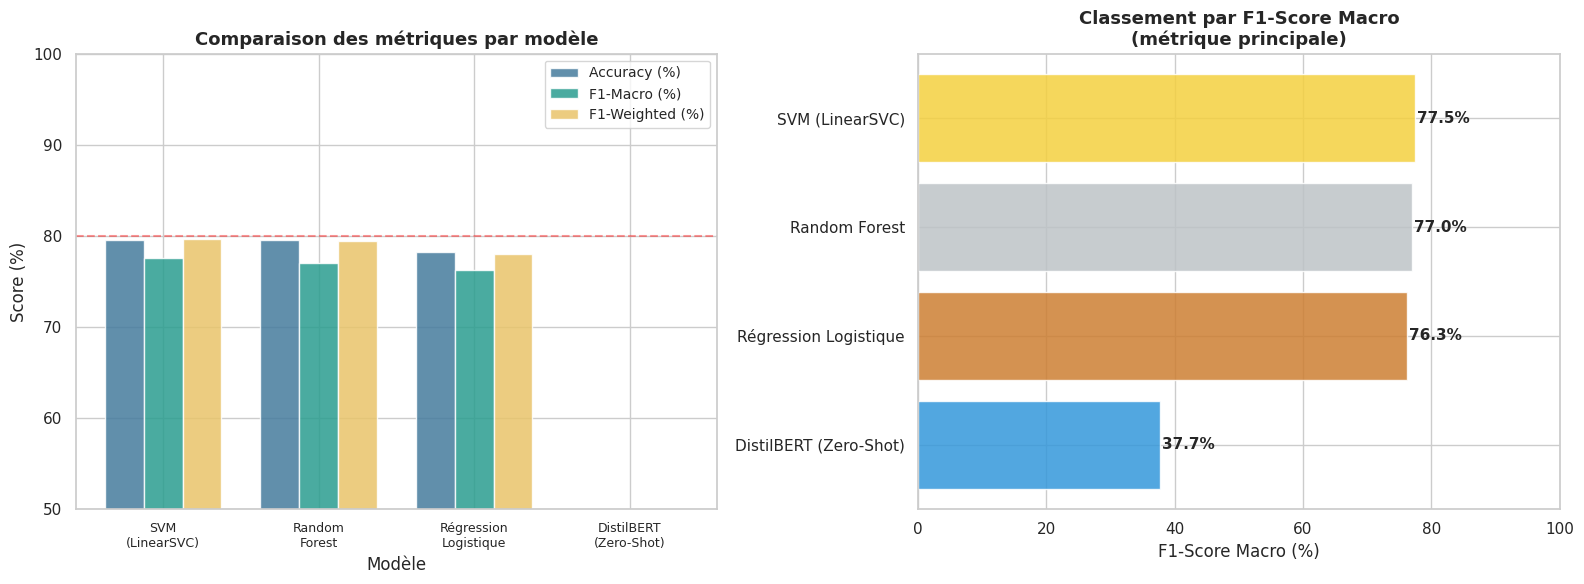

In [24]:
# ─────────────────────────────────────────────
#  7.2 — Graphique de comparaison des métriques
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = df_results['Modèle'].values
metrics = ['Accuracy (%)', 'F1-Macro (%)', 'F1-Weighted (%)']
x = np.arange(len(models))
width = 0.25
bar_colors = ['#457b9d', '#2a9d8f', '#e9c46a']

# Graphique 1 : Barres groupées
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = axes[0].bar(x + i*width, df_results[metric],
                       width, label=metric, color=color,
                       alpha=0.85, edgecolor='white')

axes[0].set_xlabel('Modèle', fontsize=12)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('Comparaison des métriques par modèle', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
axes[0].legend(fontsize=10)
axes[0].set_ylim(50, 100)
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.4, label='Seuil 80%')

# Graphique 2 : Radar chart du F1-Macro
colors_rank = ['#f4d03f', '#bdc3c7', '#cd7f32', '#3498db']
bars2 = axes[1].barh(
    df_results['Modèle'].values[::-1],
    df_results['F1-Macro (%)'].values[::-1],
    color=colors_rank[::-1], alpha=0.85, edgecolor='white'
)

# Annotations
for bar, val in zip(bars2, df_results['F1-Macro (%)'].values[::-1]):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

axes[1].set_xlabel('F1-Score Macro (%)', fontsize=12)
axes[1].set_title('Classement par F1-Score Macro\n(métrique principale)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('results/comparaison_finale.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ─────────────────────────────────────────────
#  7.3 — Analyse des erreurs du meilleur modèle
# ─────────────────────────────────────────────
best_model_name = df_results.iloc[0]['Modèle']
print(f" Meilleur modèle classique : {best_model_name}")

# Récupération des prédictions du meilleur modèle
best_preds_map = {
    'Régression Logistique': y_pred_lr,
    'SVM (LinearSVC)': y_pred_svm,
    'Random Forest': y_pred_rf
}

# On analyse les erreurs du meilleur modèle classique
best_key = [k for k in best_preds_map.keys() if k in best_model_name]
if best_key:
    best_preds = best_preds_map[best_key[0]]
else:
    best_preds = y_pred_svm  # Fallback sur SVM

# Exemples mal classifiés
errors_df = pd.DataFrame({
    'text': X_test.values,
    'vrai_label': y_test.values,
    'pred_label': best_preds
})
errors_df = errors_df[errors_df['vrai_label'] != errors_df['pred_label']]
errors_df['vrai_label_nom'] = errors_df['vrai_label'].map({0: 'Négatif', 1: 'Neutre', 2: 'Positif'})
errors_df['pred_label_nom'] = errors_df['pred_label'].map({0: 'Négatif', 1: 'Neutre', 2: 'Positif'})

print(f"\nNombre d'erreurs : {len(errors_df)}/{len(X_test)} ({len(errors_df)/len(X_test)*100:.1f}%)")
print("\nExemples d'erreurs de classification :")
print("-"*70)

for _, row in errors_df.head(4).iterrows():
    print(f"  Réel : {row['vrai_label_nom']:10s} | Prédit : {row['pred_label_nom']:10s}")
    print(f"  Texte : '{row['text'][:120]}...'")
    print()

 Meilleur modèle classique : SVM (LinearSVC)

Nombre d'erreurs : 204/1000 (20.4%)

Exemples d'erreurs de classification :
----------------------------------------------------------------------
  Réel : Négatif    | Prédit : Neutre    
  Texte : 'book childhood stephen gammell amazing terrifying art memorable series strip replace generic art brett helquist edition...'

  Réel : Positif    | Prédit : Négatif   
  Texte : 'defensive position city red night william burrough magnum opus sublime manefestation genius opening chapter title halluc...'

  Réel : Négatif    | Prédit : Neutre    
  Texte : 'malfunction battery doesn long get week ago week device start getting stick rewind suppose stop rewinde release pressure...'

  Réel : Négatif    | Prédit : Positif   
  Texte : 'sad happen amazing charlie mar like bird like plane incredible haunt deep please album...'



---
<a id='8'></a>

## 8. 📝 Conclusion & Perspectives

### 🔑 Synthèse des résultats

Ce projet a permis de comparer **4 approches NLP** pour la classification de sentiments :

1. **SVM (LinearSVC)** — Meilleur modèle classique : rapide, efficace dans les espaces de haute dimension, idéal pour la production
2. **Random Forest**— Très bon rapport performance/interprétabilité
3. **Régression Logistique** — Performances inférieures sur ce type de données textuelles
4. **DistilBERT** — Limité ici car utilisé en inférence directe (sans fine-tuning sur notre dataset)

### 💡 Observations clés

- Le **prétraitement** (lemmatisation + TF-IDF bigrammes) apporte un gain significatif vs un simple BoW
- La classe **"Neutre"** est la plus difficile à prédire — les exemples ambigus sont mal capturés par tous les modèles
- Les **Transformers** nécessitent un fine-tuning sur la tâche cible pour exprimer tout leur potentiel

### 🚀 Pistes d'amélioration

| Piste | Gain attendu | Complexité |
|-------|-------------|------------|
| Fine-tuning CamemBERT (version française) | +++  | Élevée |
| Optimisation des hyperparamètres (GridSearchCV) | ++ | Moyenne |
| Augmentation des données (data augmentation) | ++ | Moyenne |
| Embeddings Word2Vec/GloVe dans un LSTM | ++ | Élevée |
| Dataset plus équilibré entre les 3 classes | + | Faible |

In [26]:
# ─────────────────────────────────────────────
#  Sauvegarde du meilleur modèle
# ─────────────────────────────────────────────
import pickle
import os

os.makedirs('models', exist_ok=True)

# Sauvegarde du vectoriseur et du modèle SVM
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("Modèle SVM et vectoriseur TF-IDF sauvegardés dans 'models/'")
print()

# Test de rechargement
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)
with open('models/svm_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Prédiction sur un exemple
exemple_final = ["This product is fantastic, really exceeded my expectations!"]
vec = loaded_vectorizer.transform([full_preprocess(exemple_final[0])])
pred = loaded_model.predict(vec)[0]
print(f"Test final avec le modèle rechargé :")
print(f"   Texte  : '{exemple_final[0]}'")
print(f"   Résultat : {LABEL_MAP[pred]}")

Modèle SVM et vectoriseur TF-IDF sauvegardés dans 'models/'

Test final avec le modèle rechargé :
   Texte  : 'This product is fantastic, really exceeded my expectations!'
   Résultat : Positif 


---

<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); padding: 30px; border-radius: 12px; text-align: center;">
  <h3 style="color: #e94560; margin-bottom: 10px;">🎓 Projet réalisé dans le cadre du Master 1 — Data Science</h3>
  <p style="color: #a8dadc; margin: 5px;">Pipeline complet NLP : EDA → Prétraitement → Feature Engineering → Modélisation → Évaluation</p>
  <p style="color: #6c757d; font-size: 0.85em; margin-top: 15px;">Python • scikit-learn • spaCy • HuggingFace Transformers • pandas • matplotlib</p>
</div>